## Notebook for creating times-series data with bubbles

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import importlib
sys.path.append(os.path.abspath(".."))

# Import functions
from functions import simulation_master
from functions import bubble_simulation

# Reload functions
importlib.reload(simulation_master)
importlib.reload(bubble_simulation)

<module 'functions.bubble_simulation' from '/Users/tobiasfriumjordhoi/Documents/KU/Bachelor/6. semester/Bachelor/local_repo/functions/bubble_simulation.py'>

### 1. Late bubble
We set out to recreate the results found when testing for a bubble in the end of a times series. In this notebook, we will only create the time-series itself. Testing will be done elsewhere. The time-series should exhibit the following properties:
1. Monthly data in the period from jan. 1990 up to and including dec. 2025. This yields $T=12\cdot (2025-1990+1) = 432$.
2. Time-series should be non-explosive up untill AI simulated bubble, which should start around 01.01.2019 to 01.07.2023 (check code for exact date) and follow through until end of simulation. 

OBS: Below are two possible bubble-functions, where one can be commented out to more easely switch between different bubble calibrations and see results "live" in the testing notebook. 
- We obtain the desired result using the latter of the two estimations with seed=5.

Saved series to: ../data/simulated/timeseries/P_late_bubble.csv


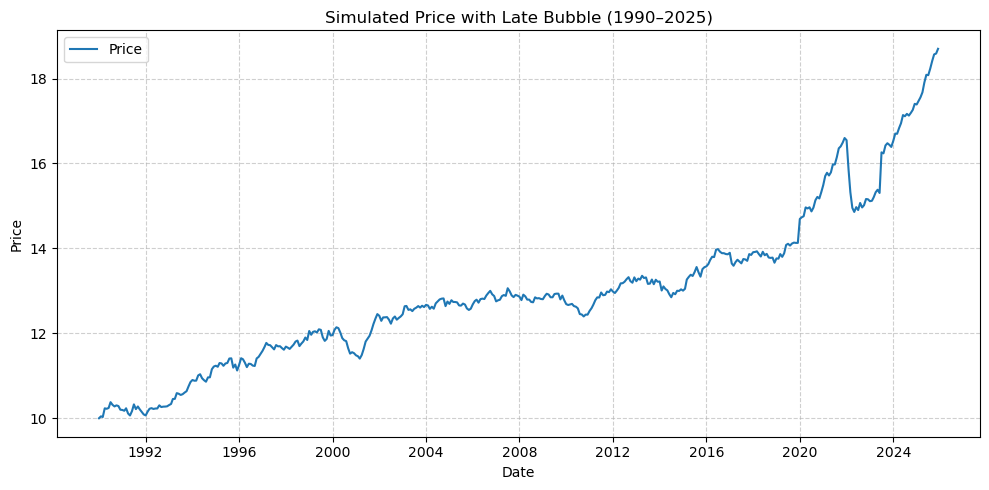

In [3]:
# Define parameters and run simulation of the price with a late bubble described above --------------------------
# Pf, B, P = simulation_master.simulate_price_with_bubbles(
#     T=432,
#     P0=10.0,
#     sigma_f=0.07,
#     mu_f=0.01,
#     rho=1.0,              # random walk fundamental

#     include_bubble=True,
#     R=0.04,               # realistic explosive growth 
#     sigma_b=0.07,         # realistic volatility 

#     # IMPORTANT: no decay phase
#     bubble_decay=1.0,     # prevents collapse

#     # Late bubble
#     t_start1=402,         # July 2023 = month 402, january 2019 = month 360, so 42 months later is july 2023
#     t_end1=431,           # runs until end of sample
#     B0_1=0.5,             # must be > 0 to be detectable

#     seed=42,
# )

Pf, B, P = simulation_master.simulate_price_with_bubbles(
    T=432,
    P0=10.0,
    sigma_f=0.08, 
    mu_f=0.01,
    rho=1.0,

    include_bubble=True,

    # fælles støj
    sigma_b=0.07,
    R=0.04,
    bubble_decay=0.6,     # vigtigt: dør hurtigt ud!

    # ---------- COVID bubble ----------
    t_start1=360,         # Jan 2020
    t_end1=384,           # Dec 2021
    B0_1=0.6,

    # ---------- AI bubble ----------
    t_start2=402,         # July 2023
    t_end2=431,
    B0_2=1.0,             # MEGET vigtig: større start

    seed=5,
)




# Save the data to a CSV file with dates as index (assuming monthly data starting from January 1990 to December 2025)
# Create monthly date index
dates = pd.date_range(start="1990-01-01", periods=432, freq="MS")  # Monthly start frequency

# Create dataframe with correct index
df = pd.DataFrame({"Price": P.values}, index=dates)

# Save to CSV WITH dates
output_path = os.path.join("..", "data", "simulated", "timeseries", "P_late_bubble.csv")
df.to_csv(output_path, index=True)

print(f"Saved series to: {output_path}")



# Plot ---------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Price"], label="Price")

# Labels og titel
plt.title("Simulated Price with Late Bubble (1990–2025)")
plt.xlabel("Date")
plt.ylabel("Price")

# Grid og legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Stram layout
plt.tight_layout()

plt.show()

#### Series with different seeds
We now wish to test rejections rates for $H_0$ when using different seeds. 
- We make $N=200$ time-series using differents seeds. 
- We save in .csv format with each column using a new seed.

In [6]:
N = 200
dates = pd.date_range(start="1990-01-01", periods=432, freq="MS")

series_list = []

for s in range(N):
    Pf, B, P = simulation_master.simulate_price_with_bubbles(
        T=432,
        P0=10.0,
        sigma_f=0.08, 
        mu_f=0.01,
        rho=1.0,

        include_bubble=True,
        sigma_b=0.07,
        R=0.04,
        bubble_decay=0.6,

        t_start1=360,
        t_end1=384,
        B0_1=0.6,

        t_start2=402,
        t_end2=431,
        B0_2=1.0,

        seed=s,
    )

    # Gem som serie
    series = pd.Series(P.values, index=dates, name=f"seed_{s}")
    series_list.append(series)

# Saml alle på én gang (ingen fragmentation!)
panel_df = pd.concat(series_list, axis=1)
panel_df.index.name = "Date"

# Gem
output_path = os.path.join("..", "data", "simulated", "timeseries", "P_late_bubble_multi_seeds.csv")
panel_df.to_csv(output_path)

print(f"Saved panel data to: {output_path}")

Saved panel data to: ../data/simulated/timeseries/P_late_bubble_multi_seeds.csv
